In [1]:
#****** Import Libraries *******
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path
import warnings

# Suppress runtime warning
warnings.filterwarnings("ignore")

In [2]:
project_path = Path.cwd()                         # Get the current working directory
data_path = project_path / "data/normal.xlsx"     

In [3]:
#****** Data Loading & Preprocessing ******
df = pd.read_excel(data_path) 

df.head()

,Feed - Liq Vol Flow @Std Cond,Feed - Pressure,Feed - Temperature,Seperator_in - Liq Vol Flow @Std Cond,Seperator_in - Pressure,Seperator_in - Temperature,LL_1 - Liq Vol Flow @Std Cond,LL_1 - Pressure,LL_1 - Temperature,GV_1 - Liq Vol Flow @Std Cond,...,Gas Injection - Temperature,Treatment - Liq Vol Flow @Std Cond,Treatment - Pressure,Treatment - Temperature,Flares - Liq Vol Flow @Std Cond,Flares - Pressure,Flares - Temperature,To Turbines - Liq Vol Flow @Std Cond,To Turbines - Pressure,To Turbines - Temperature
0,[m3/h],[kPa],[C],[m3/h],[kPa],[C],[m3/h],[kPa],[C],[m3/h],...,[C],[m3/h],[kPa],[C],[m3/h],[kPa],[C],[m3/h],[kPa],[C]
1,253415,9000,83,253415,8901.99,82.7844,37.3479,8901.99,82.762,221010,...,127.142,10739.5,4021.02,66.4564,332.804,930,47.8641,10108.2,1825,46.2311
2,252996,9000,83,252996,8902.13,82.7844,37.3468,8902.13,82.762,221014,...,127.142,10739.6,4021.02,66.4564,332.802,930,47.8629,10108.2,1825,46.2311
3,252771,9000,83,252771,8902.2,82.7849,37.3463,8902.2,82.7623,220891,...,127.138,10739.8,4021.02,66.4556,332.803,930,47.8629,10108.2,1825,46.2311
4,252599,9000,83,252599,8902.23,82.7849,37.3444,8902.23,82.7624,220701,...,127.138,10739.9,4021.02,66.4556,332.802,930,47.8651,10108.2,1825,46.2311


In [4]:
# Drop the first row of the DataFrame (it contains units, not data)
df = df.iloc[1:, :]

# Convert all columns to numeric numpy array of floats
data = df.values.astype(float)  

print("Data shape:", data.shape)

Data shape: (10801, 105)


In [ ]:
#************ Train/val split *****************
T = data.shape[0]

# first 80% for training, last 20% for validation
train_size = int(0.8 * T)
X_train = data[:train_size, :]
X_val = data[train_size:, :]

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (8640, 105)
Val shape: (2161, 105)


In [6]:
#************** Feature Scaling (Standardization) ***************
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

In [7]:
#************* PCA Analysis *********************
# PCA analysis is done to obtain an approximate low-dimensional space (bottleneck)
pca = PCA()
pca.fit(X_train_scaled)

# Explained variance per component 
explained_var = pca.explained_variance_ratio_ * 100
cum_explained_var = np.cumsum(explained_var)

# PCs that explained 90%, 95% and 99% of the total variance
d90 = np.argmax(cum_explained_var >= 90) + 1
d95 = np.argmax(cum_explained_var >= 95) + 1
d99 = np.argmax(cum_explained_var >= 99) + 1

print(f"Components for 90% variance: {d90}")
print(f"Components for 95% variance: {d95}")
print(f"Components for 99% variance: {d99}")

Components for 90% variance: 3
Components for 95% variance: 4
Components for 99% variance: 7


In [ ]:
# Create a DataFrame to display explained variance information
explained_var_df = pd.DataFrame({
    'Principal Component': np.arange(1, len(explained_var) + 1),
    'Explained Variance (%)': explained_var,
    'Cumulative Explained Variance (%)': cum_explained_var
})

# Display the first 10 rows of the explained variance DataFrame
explained_var_df.head(10)

,Principal Component,Explained Variance (%),Cumulative Explained Variance (%)
0,1,43.202510,43.202510
1,2,28.317067,71.519576
2,3,23.156469,94.676045
3,4,1.358581,96.034626
4,5,1.111824,97.146450
5,6,1.008943,98.155393
6,7,0.921766,99.077158
7,8,0.384760,99.461918
8,9,0.261185,99.723104
9,10,0.174267,99.897371


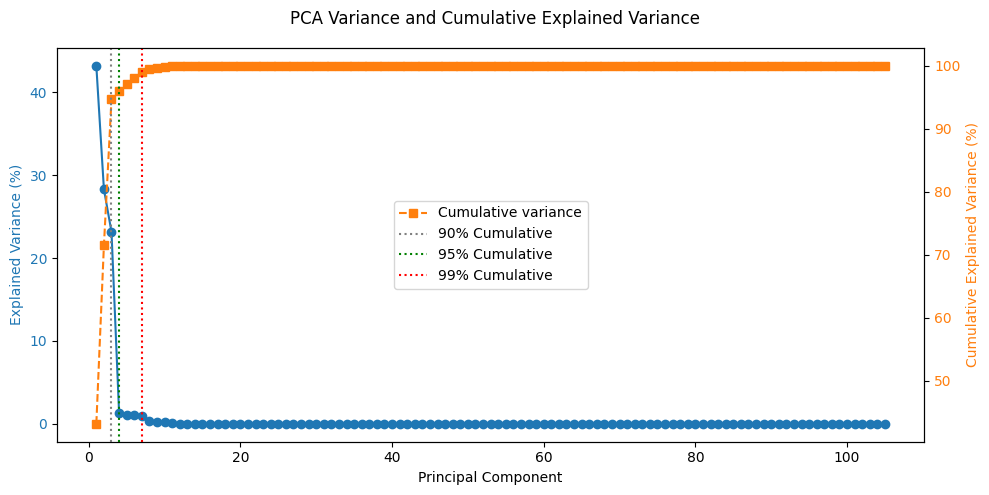

In [ ]:
#******Visualization of explained variance ******#

# X-axis: Principal components (1, 2, 3, ...)
components = np.arange(1, len(explained_var) + 1)

# Visualization
fig, ax1 = plt.subplots(figsize=(10,5))

color = 'tab:blue'
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color=color)
ax1.plot(components, explained_var, 'o-', color=color, label='Individual variance')
ax1.tick_params(axis='y', labelcolor=color)
# ax1.legend()

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Cumulative Explained Variance (%)', color=color)
ax2.plot(components, cum_explained_var, 's--', color=color, label='Cumulative variance')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axvline(x=d90, color='gray', linestyle=':', label="90% Cumulative")  
ax2.axvline(x=d95, color='green', linestyle=':', label="95% Cumulative")  
ax2.axvline(x=d99, color='red', linestyle=':', label="99% Cumulative") 
ax2.legend(loc='center') 
fig.suptitle('PCA Variance and Cumulative Explained Variance')
fig.tight_layout()
plt.show()

In [13]:
# From the plot, the best low-dimension representation (latent space) is 7, which explains about 99% of the variance in the data.
d = 7
d_var = cum_explained_var[d-1]
print(f"Bottleneck size: {d}")
print(f"Cumulative variance explained: {d_var:.2f}%")

Bottleneck size: 7
Cumulative variance explained: 99.08%


In [14]:
# Error
pca = PCA(n_components=d)
X_train_recon = pca.inverse_transform(pca.fit_transform(X_train_scaled))
recon_error = np.mean((X_train_scaled - X_train_recon)**2)
print(f"PCA reconstruction MSE with {d} components: {recon_error:.4e}")

PCA reconstruction MSE with 7 components: 8.0858e-03
